# 03 — Case39: every figure and table from cached results

Runs the case39 figure scripts in `code/case39/scripts/` (seconds) and prints Table 2. The
narrative notebooks in `notebooks/case39_narrative/` explain each experiment family in detail;
the heavy recomputation order is documented in `code/case39/scripts/recompute_notes.py`.

In [1]:
import subprocess, sys
from pathlib import Path
import pandas as pd
ROOT = Path.cwd().parent
C39 = ROOT / "code" / "case39"
for s in ["make_figures.py", "make_control_inflation_hierarchy_figures.py", "make_reinforcement_planning_figures.py"]:
    r = subprocess.run([sys.executable, f"scripts/{s}"], cwd=C39, capture_output=True, text=True)
    msg = (r.stdout + r.stderr).strip().splitlines()
    print(s, "->", msg[-1] if msg else f"exit code {r.returncode}")

make_figures.py -> wrote figures to /home/claude/sjco/repo/code/case39/figures


make_control_inflation_hierarchy_figures.py ->   axs[rowi,1].set_title(title+': $\mathcal{J}^+-\mathcal{J}^-$')


make_reinforcement_planning_figures.py -> exit code 0


## Table 2: the actuator hierarchy at $\sigma_{\rm rms}=0.1$

In [2]:
t = pd.read_csv(C39 / "results" / "control_inflation_hierarchy_combined.csv")
t = t[t.sigma_rms == 0.10].rename(columns={"Wminus": "J_minus", "Wplus": "J_plus", "inflation_trace": "I_burden"})
t["J_minus_J_plus_gap"] = t.J - t.J_plus
t[["noise", "H", "J", "J_minus", "J_plus", "I_burden", "lambda_max", "J_minus_J_plus_gap"]].round(5)

,noise,H,J,J_minus,J_plus,I_burden,lambda_max,J_minus_J_plus_gap
4,homogeneous,H0,0.09573,0.05770,0.08465,190.00000,0.00200,0.01108
5,homogeneous,H1,0.09584,0.05778,0.08465,190.00000,0.00200,0.01120
6,homogeneous,H2,0.09270,0.05511,0.08465,180.00000,0.00200,0.00805
7,homogeneous,H3,0.09156,0.05619,0.08465,145.00000,0.00200,0.00691
20,activity_scaled,H0,0.08301,0.05816,0.07846,62.39343,0.00579,0.00455
21,activity_scaled,H1,0.08314,0.05779,0.07207,166.83036,0.00227,0.01107
22,activity_scaled,H2,0.08004,0.05501,0.06882,241.31785,0.00152,0.01122
23,activity_scaled,H3,0.07878,0.05414,0.05318,744.50580,0.00049,0.02560


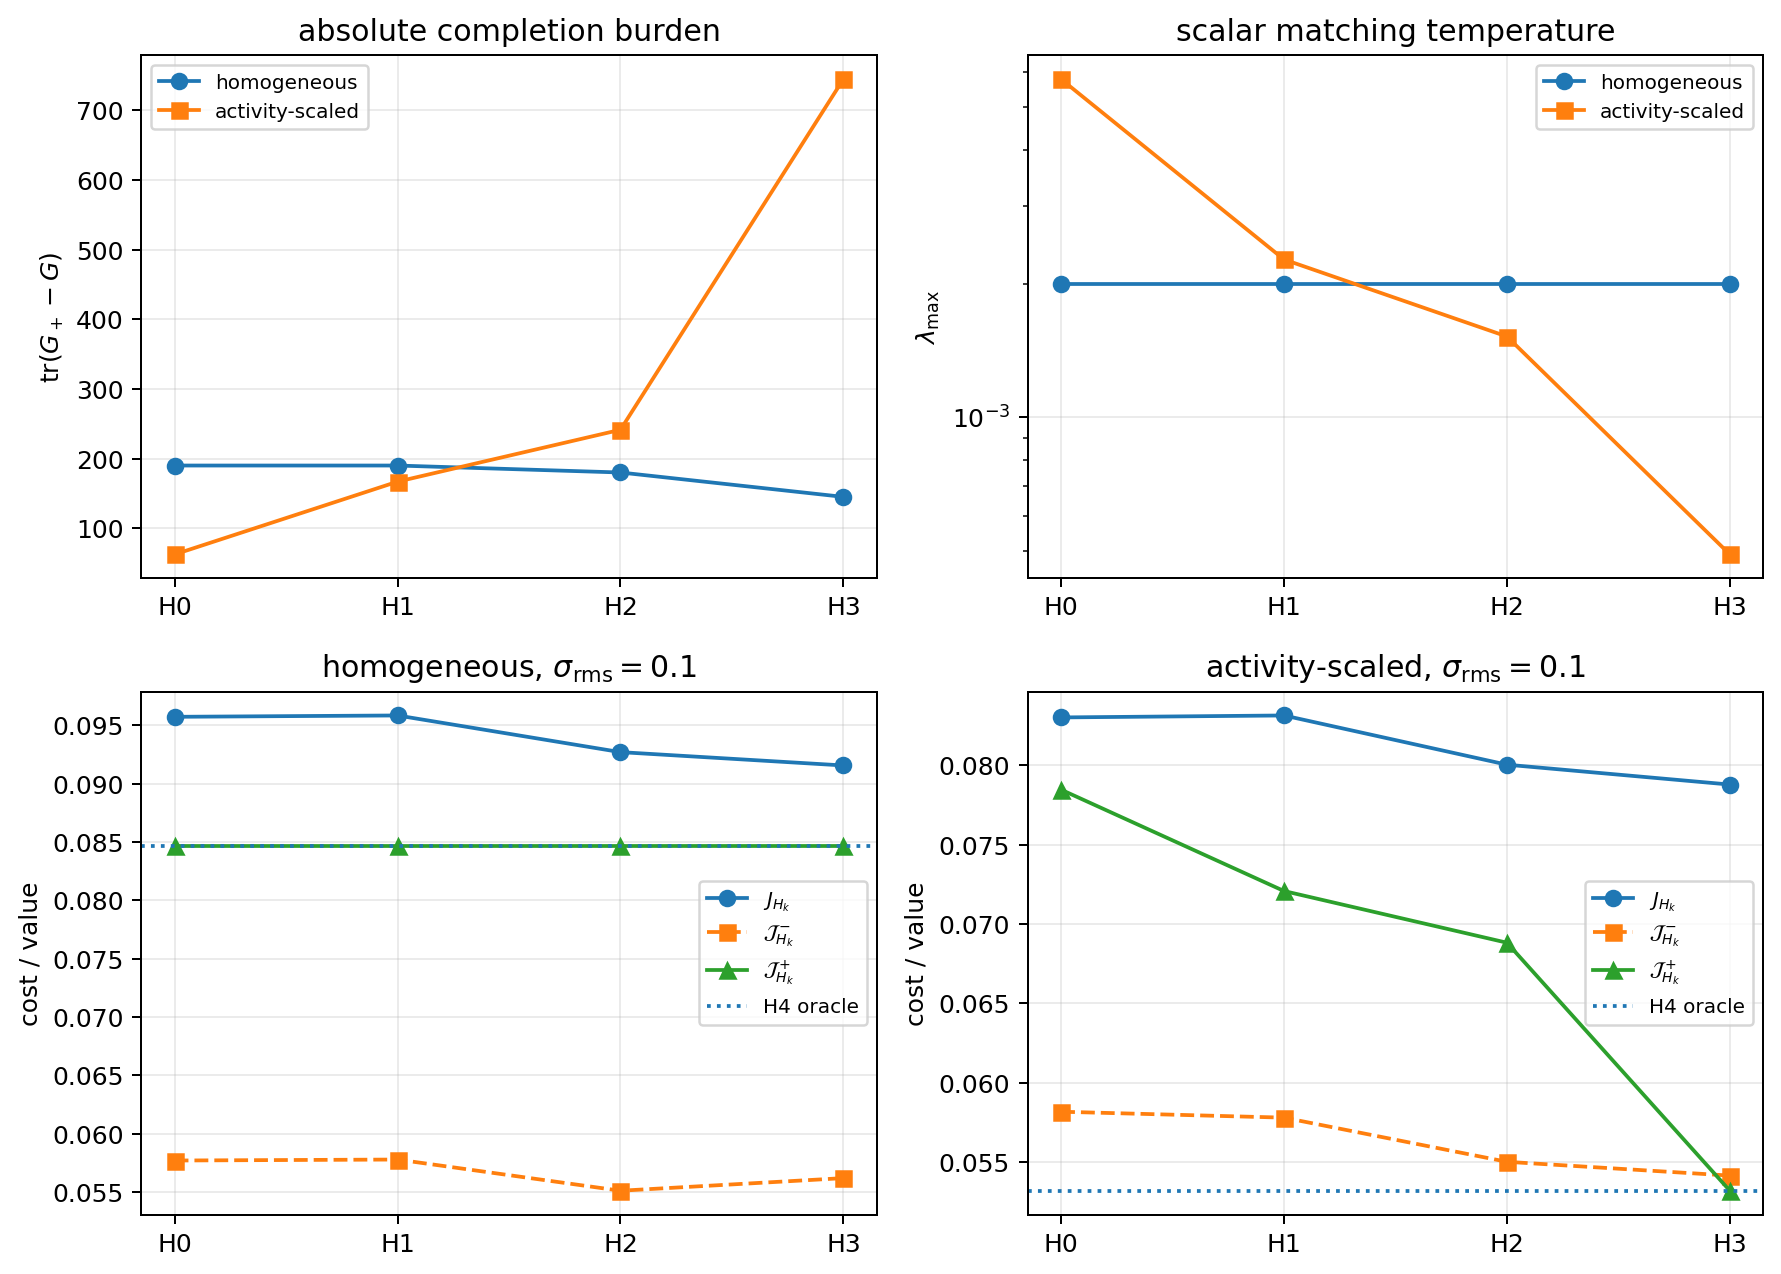

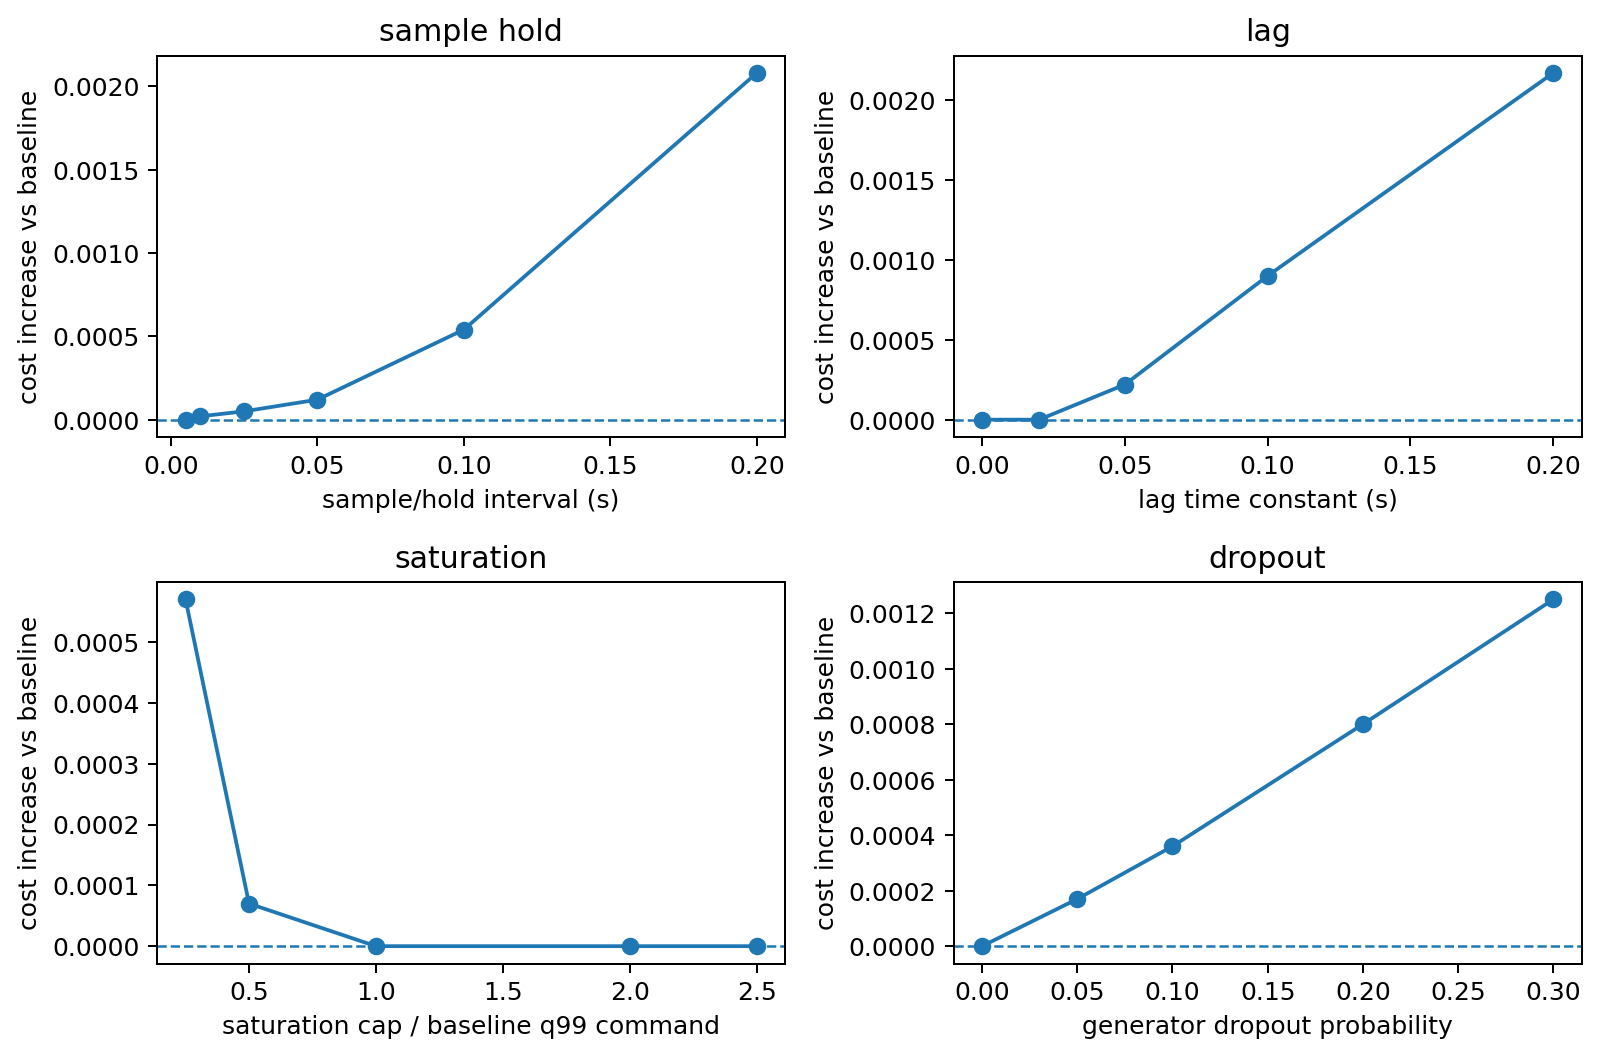

In [3]:
from IPython.display import Image, display
for name in ["case39_control_inflation_hierarchy", "case39_implementation"]:
    display(Image(filename=str(C39 / "figures" / f"{name}.png"), width=720))